# Sentiment Analysis — Amazon Product Reviews

**Disciplina:** Engenharia de Software para IA e Frameworks Profundos  
**Dataset:** Amazon Product Reviews (Kaggle: yasserh)

---
> **Como usar:** Execute **Kernel → Restart & Run All** para rodar todas as entregas de uma vez.

In [40]:
import sys, os
from pathlib import Path

# VS Code injeta __vsc_ipynb_file__ com o caminho absoluto do notebook.
# Isso resolve o cwd incorreto independente de onde o Jupyter foi aberto.
if "__vsc_ipynb_file__" in dir():
    ROOT = str(Path(__vsc_ipynb_file__).parent.parent)
else:
    # Fallback para Jupyter clássico: sobe na árvore procurando main.py
    for p in [Path(os.getcwd())] + list(Path(os.getcwd()).parents):
        if (p / "main.py").exists() and (p / "requirements.txt").exists():
            ROOT = str(p)
            break
    else:
        raise RuntimeError(
            "Raiz do projeto não encontrada.\n"
            "Abra o notebook pelo VS Code ou execute o Jupyter de dentro da pasta do projeto."
        )

os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

print(f"ROOT  : {ROOT}")
print(f"CWD   : {os.getcwd()}")
assert os.path.exists("data/raw/reviews.csv"), "ERRO: data/raw/reviews.csv não encontrado!"
print("Dataset: OK")

ROOT  : c:\Users\cliberato\Desktop\UFPE\Engenharia de Software\project-sentiment-analysis
CWD   : c:\Users\cliberato\Desktop\UFPE\Engenharia de Software\project-sentiment-analysis
Dataset: OK


---
## Entrega 1 — Funções, Modularização e Tipagem
> Etapas 1, 2 e 3

Código organizado em módulos com responsabilidades separadas. Todas as funções têm type hints.

```
src/
├── data/loader.py              carregamento e validação
├── preprocessing/transform.py  limpeza de texto e labels
├── models/model.py             definição do modelo
├── training/train.py           pipeline de treinamento
├── evaluation/metrics.py       métricas de avaliação
├── inference/predict.py        inferência em produção
└── utils/config.py             constantes e hiperparâmetros
```

In [41]:
import inspect
from src.data.loader import load_data, validate_columns, inspect_data
from src.preprocessing.transform import clean_text, normalize_label, preprocess_dataset

print("=== Assinaturas tipadas das funções públicas ===")
for fn in [load_data, validate_columns, inspect_data, clean_text, normalize_label, preprocess_dataset]:
    print(f"  def {fn.__name__}{inspect.signature(fn)}")

print("\n=== Demonstração: clean_text e normalize_label ===")
casos = [("This is GREAT!!!", 5), ("Terrible product...", 1), ("It's okay.", 3)]
print(f"{'Texto original':<28} {'clean_text':<28} {'label'}")
print("-" * 68)
for texto, rating in casos:
    print(f"{texto:<28} {clean_text(texto):<28} {normalize_label(rating)}")

=== Assinaturas tipadas das funções públicas ===
  def load_data(path: str) -> pandas.core.frame.DataFrame
  def validate_columns(df: pandas.core.frame.DataFrame, required: list[str]) -> None
  def inspect_data(df: pandas.core.frame.DataFrame) -> None
  def clean_text(text: 'str') -> 'str'
  def normalize_label(rating: 'int') -> 'int | None'
  def preprocess_dataset(df: 'pd.DataFrame') -> 'pd.DataFrame'

=== Demonstração: clean_text e normalize_label ===
Texto original               clean_text                   label
--------------------------------------------------------------------
This is GREAT!!!             this is great                1
Terrible product...          terrible product             0
It's okay.                   its okay                     None


---
## Entrega 2 — NumPy
> Etapa 4

- `inspect_data` → `np.min`, `np.max`, `np.mean`, `np.std`, `np.unique`
- `vectorize_texts` → TF-IDF `.toarray()` → matriz densa NumPy
- `normalize_features` → normalização L2 com `np.linalg.norm`

In [42]:
import numpy as np
from src.data.loader import load_data, inspect_data
from src.preprocessing.transform import preprocess_dataset, vectorize_texts, normalize_features
from src.training.train import split_dataset
from src.utils.config import DATA_PATH, TEXT_COLUMN, LABEL_COLUMN, TEST_SIZE, MAX_FEATURES

df = load_data(DATA_PATH)
print("=== Análise NumPy do dataset ===")
inspect_data(df)

df_clean = preprocess_dataset(df)
print(f"\nAmostras após pré-processamento: {len(df_clean)}")
print(f"Distribuição:\n{df_clean[LABEL_COLUMN].value_counts().to_string()}")

x_train, x_test, y_train, y_test = split_dataset(df_clean, TEXT_COLUMN, LABEL_COLUMN, TEST_SIZE)

vectorizer, X_train_np = vectorize_texts(x_train, MAX_FEATURES)
X_test_np = vectorizer.transform(x_test).toarray()
print(f"\n=== Antes da normalização ===")
print(f"X_train shape : {X_train_np.shape}")
print(f"Norma média   : {np.linalg.norm(X_train_np, axis=1).mean():.4f}")

X_train_np = normalize_features(X_train_np)
X_test_np  = normalize_features(X_test_np)
print(f"\n=== Após normalização L2 ===")
print(f"Norma média   : {np.linalg.norm(X_train_np, axis=1).mean():.4f}  ← deve ser ≈ 1.0")

=== Análise NumPy do dataset ===
Total samples  : 1597
Total columns  : 27
Rating min/max : 1 / 5
Rating mean    : 4.36
Rating std     : 1.02
  Rating 1: 42 reviews
  Rating 2: 34 reviews
  Rating 3: 124 reviews
  Rating 4: 236 reviews
  Rating 5: 741 reviews

Amostras após pré-processamento: 1053
Distribuição:
sentiment
1    977
0     76

=== Antes da normalização ===
X_train shape : (842, 2000)
Norma média   : 0.9976

=== Após normalização L2 ===
Norma média   : 0.9976  ← deve ser ≈ 1.0


---
## Entrega 3 — PyTorch Parte 1: Tensores, Dataset e DataLoader
> Etapa 5

In [43]:
import torch
from src.training.train import to_tensors, create_dataloader
from src.utils.config import BATCH_SIZE

X_train_t, y_train_t = to_tensors(X_train_np, y_train.to_numpy())
X_test_t,  y_test_t  = to_tensors(X_test_np,  y_test.to_numpy())
train_loader = create_dataloader(X_train_t, y_train_t, BATCH_SIZE)
val_loader   = create_dataloader(X_test_t,  y_test_t,  BATCH_SIZE, shuffle=False)

print("=== Tensores PyTorch ===")
print(f"X_train : {X_train_t.shape} | {X_train_t.dtype}")
print(f"y_train : {y_train_t.shape} | {y_train_t.dtype}")
print(f"\n=== DataLoaders ===")
print(f"Batches treino    : {len(train_loader)}")
print(f"Batches validação : {len(val_loader)}")
print(f"Device            : {'cuda' if torch.cuda.is_available() else 'cpu'}")
Xb, yb = next(iter(train_loader))
print(f"\nBatch exemplo: X={Xb.shape}, y={yb.shape}")

=== Tensores PyTorch ===
X_train : torch.Size([842, 2000]) | torch.float32
y_train : torch.Size([842]) | torch.float32

=== DataLoaders ===
Batches treino    : 14
Batches validação : 4
Device            : cpu

Batch exemplo: X=torch.Size([64, 2000]), y=torch.Size([64])


---
## Entrega 4 — PyTorch Parte 2: Modelo, Treinamento e Inferência
> Etapa 6

In [44]:
import torch.nn as nn
from src.models.model import build_model, save_model, load_model, predict
from src.utils.config import HIDDEN_DIM, OUTPUT_DIM, MODEL_PATH

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model(MAX_FEATURES, HIDDEN_DIM, OUTPUT_DIM).to(device)
print("=== Arquitetura SentimentMLP ===")
print(model)
print(f"\nParâmetros: {sum(p.numel() for p in model.parameters()):,}")

=== Arquitetura SentimentMLP ===
SentimentMLP(
  (network): Sequential(
    (0): Linear(in_features=2000, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=1, bias=True)
  )
)

Parâmetros: 512,513


In [46]:
from src.training.train import run_training
from src.utils.config import LEARNING_RATE, NUM_EPOCHS

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()
print("=== Loop de Treinamento + Validação ===")
model = run_training(model, train_loader, val_loader, optimizer, criterion, NUM_EPOCHS, device)

=== Loop de Treinamento + Validação ===
Epoch  1/10 — train_loss: 0.1299 | val_loss: 0.1682
Epoch  2/10 — train_loss: 0.1105 | val_loss: 0.1557
Epoch  3/10 — train_loss: 0.1065 | val_loss: 0.1463
Epoch  4/10 — train_loss: 0.0796 | val_loss: 0.1412
Epoch  5/10 — train_loss: 0.0689 | val_loss: 0.1373
Epoch  6/10 — train_loss: 0.0573 | val_loss: 0.1366
Epoch  7/10 — train_loss: 0.0495 | val_loss: 0.1360
Epoch  8/10 — train_loss: 0.0377 | val_loss: 0.1347
Epoch  9/10 — train_loss: 0.0330 | val_loss: 0.1377
Epoch 10/10 — train_loss: 0.0266 | val_loss: 0.1399


=== Métricas ===
accuracy    : 0.9573
f1_score    : 0.9778
precision   : 0.9565
recall      : 1.0000


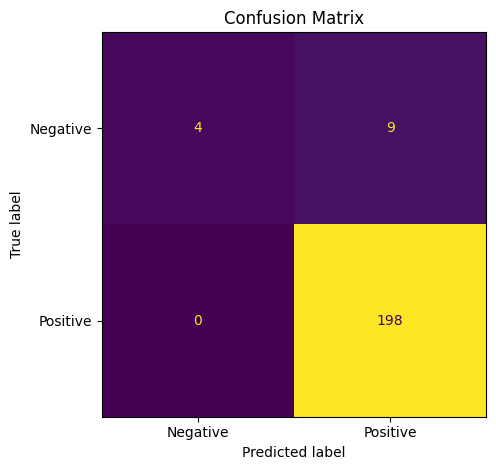

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from src.evaluation.metrics import evaluate_model, print_report

y_pred = predict(model, X_test_t, device)
metrics = evaluate_model(y_test.to_numpy(), y_pred)
print("=== Métricas ===")
print_report(metrics)

ConfusionMatrixDisplay(confusion_matrix(y_test.to_numpy(), y_pred),
                       display_labels=["Negative", "Positive"]).plot(colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [48]:
save_model(model, MODEL_PATH)
model_reloaded = load_model(MODEL_PATH, MAX_FEATURES, HIDDEN_DIM, OUTPUT_DIM)
m2 = evaluate_model(y_test.to_numpy(), predict(model_reloaded, X_test_t, torch.device("cpu")))
print(f"Accuracy original : {metrics['accuracy']:.4f}")
print(f"Accuracy reloaded : {m2['accuracy']:.4f}  ← deve ser idêntica")

Accuracy original : 0.9573
Accuracy reloaded : 0.9573  ← deve ser idêntica


In [49]:
from src.inference.predict import predict_batch

exemplos = [
    "This product is absolutely amazing, I love it!",
    "Terrible quality, broke after one day. Total waste of money.",
    "Best purchase I have ever made, highly recommend!",
    "Very disappointed, does not work at all.",
]
print("=== Inferência ===")
for texto, lbl in zip(exemplos, predict_batch(exemplos, model, vectorizer, device)):
    print(f"  [{'POSITIVE' if lbl else 'NEGATIVE'}] {texto}")

=== Inferência ===
  [POSITIVE] This product is absolutely amazing, I love it!
  [NEGATIVE] Terrible quality, broke after one day. Total waste of money.
  [POSITIVE] Best purchase I have ever made, highly recommend!
  [NEGATIVE] Very disappointed, does not work at all.


---
## Entrega 5 — Exercícios Intermediários
> Etapa 7

Epoch  1/10 — train_loss: 0.6456 | val_loss: 0.5550
Epoch  2/10 — train_loss: 0.4798 | val_loss: 0.3758
Epoch  3/10 — train_loss: 0.3270 | val_loss: 0.2771
Epoch  4/10 — train_loss: 0.2624 | val_loss: 0.2441
Epoch  5/10 — train_loss: 0.2621 | val_loss: 0.2316
Epoch  6/10 — train_loss: 0.2096 | val_loss: 0.2212
Epoch  7/10 — train_loss: 0.1930 | val_loss: 0.2099
Epoch  8/10 — train_loss: 0.1768 | val_loss: 0.1973
Epoch  9/10 — train_loss: 0.1685 | val_loss: 0.1845
Epoch 10/10 — train_loss: 0.1404 | val_loss: 0.1719
Epoch  1/10 — train_loss: 0.5968 | val_loss: 0.4568
Epoch  2/10 — train_loss: 0.3521 | val_loss: 0.2758
Epoch  3/10 — train_loss: 0.2446 | val_loss: 0.2385
Epoch  4/10 — train_loss: 0.2298 | val_loss: 0.2270
Epoch  5/10 — train_loss: 0.2038 | val_loss: 0.2115
Epoch  6/10 — train_loss: 0.1839 | val_loss: 0.1947
Epoch  7/10 — train_loss: 0.1585 | val_loss: 0.1795
Epoch  8/10 — train_loss: 0.1271 | val_loss: 0.1641
Epoch  9/10 — train_loss: 0.1111 | val_loss: 0.1517
Epoch 10/10 

,accuracy,f1_score,precision,recall
Config,,,,
Baseline,0.9431,0.9706,0.9429,1.0
Rede maior,0.9526,0.9754,0.9519,1.0


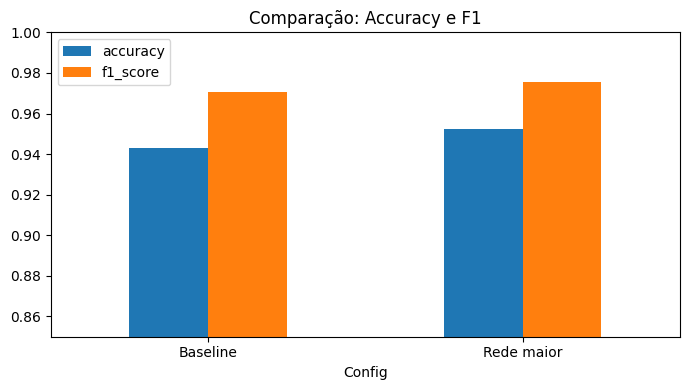


ΔF1 (Rede maior vs Baseline) = +0.0048
Dataset pequeno: mais parâmetros não garante ganho expressivo.


In [50]:
import pandas as pd

configs = [
    {"name": "Baseline",   "hidden_dim": 256, "lr": 1e-3, "epochs": 10},
    {"name": "Rede maior", "hidden_dim": 512, "lr": 1e-3, "epochs": 10},
]
resultados = []
for cfg in configs:
    m = build_model(MAX_FEATURES, cfg["hidden_dim"], OUTPUT_DIM).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=cfg["lr"])
    run_training(m, train_loader, val_loader, opt, nn.BCEWithLogitsLoss(), cfg["epochs"], device)
    met = evaluate_model(y_test.to_numpy(), predict(m, X_test_t, device))
    resultados.append({"Config": cfg["name"], **{k: round(v, 4) for k, v in met.items()}})

df_res = pd.DataFrame(resultados).set_index("Config")
print("=== Tabela de Resultados ===")
display(df_res)

df_res[["accuracy", "f1_score"]].plot(kind="bar", figsize=(7, 4), ylim=(0.85, 1.0))
plt.title("Comparação: Accuracy e F1")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

diff = df_res.loc["Rede maior", "f1_score"] - df_res.loc["Baseline", "f1_score"]
print(f"\nΔF1 (Rede maior vs Baseline) = {diff:+.4f}")
print("Dataset pequeno: mais parâmetros não garante ganho expressivo.")

---
## Entrega 6 — Testes Automatizados com unittest
> Etapa 8

In [51]:
import unittest
suite  = unittest.TestLoader().discover(start_dir="tests", pattern="test_*.py")
result = unittest.TextTestRunner(verbosity=2).run(suite)
print(f"\nTotal: {result.testsRun} | Falhas: {len(result.failures)} | Erros: {len(result.errors)}")

test_load_data_raises_file_not_found (test_data.TestLoadData)
load_data should raise FileNotFoundError for a non-existent path. ... ok
test_load_data_returns_dataframe (test_data.TestLoadData)
load_data should return a DataFrame when given a valid CSV file. ... ok
test_passes_with_required_columns (test_data.TestValidateColumns)
validate_columns should not raise when all required columns are present. ... ok
test_raises_on_missing_column (test_data.TestValidateColumns)
validate_columns should raise ValueError when a column is missing. ... ok
test_save_and_load (test_model.TestSaveLoadModel) ... ok
test_forward_output_shape (test_model.TestSentimentMLP) ... ok
test_predict_length_matches_input (test_model.TestSentimentMLP) ... ok
test_predict_output_is_binary (test_model.TestSentimentMLP) ... ok
test_predict_returns_ndarray (test_model.TestSentimentMLP) ... ok
test_converts_to_lowercase (test_preprocessing.TestCleanText) ... ok
test_removes_extra_spaces (test_preprocessing.TestCleanText)

Epoch  1/2 — train_loss: 0.7440 | val_loss: 0.5795
Epoch  2/2 — train_loss: 0.7217 | val_loss: 0.5827


test_returns_float (test_training.TestTrainEpoch) ... ok
test_loss_is_positive (test_training.TestValidateEpoch) ... ok
test_returns_float (test_training.TestValidateEpoch) ... ok

----------------------------------------------------------------------
Ran 26 tests in 1.878s

OK



Total: 26 | Falhas: 0 | Erros: 0


---
## Entrega 7 — Visão do Sistema, Requisitos e Arquitetura
> Etapas 9, 10 e 11

In [52]:
from IPython.display import Markdown, display
for doc in ["docs/vision.md", "docs/requirements.md", "docs/architecture.md"]:
    print(f"\n{'='*60}\n  {doc}\n{'='*60}")
    with open(doc, encoding="utf-8") as f:
        display(Markdown(f.read()))


  docs/vision.md


# Visão do Sistema

## Nome do Projeto
Sentiment Analysis — Amazon Product Reviews

## Problema
Plataformas de e-commerce acumulam milhares de reviews de produtos diariamente. A leitura manual é inviável, e decisões de negócio que dependem do sentimento dos clientes ficam atrasadas. O sistema automatiza a classificação de sentimento de reviews textuais.

## Público-alvo
- Equipes de produto e marketing que precisam monitorar a satisfação de clientes em escala.
- Desenvolvedores e pesquisadores que desejam integrar classificação de sentimento em pipelines de dados.
- Estudantes de IA e Engenharia de Software que buscam um exemplo completo de sistema de ML em produção.

## Justificativa
A classificação binária de sentimento (positivo/negativo) é um problema bem definido com dataset público disponível, permitindo validação objetiva via métricas de accuracy, F1, precision e recall. O uso de PyTorch garante extensibilidade para arquiteturas mais complexas em entregas futuras.

## Escopo

**Inclui:**
- Carregamento e validação do dataset Amazon Product Reviews
- Pré-processamento de texto (limpeza, normalização)
- Vetorização TF-IDF com NumPy
- Classificação binária com MLP PyTorch
- Avaliação com métricas padrão
- Inferência sobre textos novos
- Testes automatizados com unittest
- Documentação de requisitos e arquitetura

**Não inclui:**
- Interface gráfica ou API REST
- Suporte a idiomas além do inglês
- Análise de sentimento multi-classe (neutro não é classificado)
- Retreinamento online com novos dados

## Limitações
- O modelo é sensível ao tamanho do vocabulário TF-IDF (`MAX_FEATURES=2000`); reviews muito curtos podem ter representação pobre.
- Reviews com rating 3 (neutro) são descartados — o sistema não classifica sentimentos ambíguos.
- O desempenho foi avaliado apenas no dataset Amazon Product Reviews; generalização para outros domínios não foi validada.
- O modelo atual (MLP sobre TF-IDF) não captura contexto sequencial; arquiteturas como LSTM ou Transformers podem ser superiores.

## Possíveis Impactos
- **Positivo:** redução do tempo de análise de feedback de clientes, identificação rápida de problemas em produtos.
- **Positivo:** base para sistemas de recomendação ou alertas automáticos de qualidade de produto.
- **Atenção:** classificações incorretas podem influenciar decisões de negócio; o sistema deve ser usado como apoio, não como árbitro final.
- **Atenção:** o dataset de treino pode conter vieses de seleção (produtos com mais reviews tendem a ser mais populares).



  docs/requirements.md


# Documentação de Requisitos

## Requisitos Funcionais

| ID | Descrição |
|----|-----------|
| RF01 | O sistema deve carregar a base de dados de reviews em formato CSV. |
| RF02 | O sistema deve pré-processar os textos removendo pontuação, convertendo para minúsculas e colapsando espaços. |
| RF03 | O sistema deve converter ratings numéricos em labels binários de sentimento (positivo/negativo), descartando reviews neutros (rating = 3). |
| RF04 | O sistema deve vetorizar os textos usando TF-IDF e normalizar os vetores com NumPy. |
| RF05 | O sistema deve treinar um modelo de rede neural (MLP) em PyTorch para classificação binária de sentimento. |
| RF06 | O sistema deve avaliar o modelo com métricas de accuracy, F1-score, precision e recall. |
| RF07 | O sistema deve realizar inferência (predição de sentimento) sobre novos textos. |
| RF08 | O sistema deve salvar os resultados dos experimentos (métricas, figuras, modelo treinado). |

## Requisitos Não Funcionais

| ID | Descrição |
|----|-----------|
| RNF01 | O código deve ser modularizado em pacotes com responsabilidades separadas. |
| RNF02 | O sistema deve ser reproduzível: mesma semente aleatória (`RANDOM_SEED=42`) deve gerar os mesmos resultados. |
| RNF03 | O sistema deve possuir testes automatizados com `unittest` cobrindo carregamento, pré-processamento, modelo e treinamento. |
| RNF04 | O sistema deve utilizar tipagem estática em todas as funções públicas. |
| RNF05 | O sistema deve ser versionado com Git, com histórico de commits rastreável. |
| RNF06 | O sistema deve possuir documentação de execução no README. |
| RNF07 | O modelo deve apresentar desempenho mensurável por accuracy, F1, precision e recall, salvos em `results/metrics/metrics.json`. |
| RNF08 | O sistema deve funcionar em CPU, com suporte opcional a GPU via PyTorch. |

## Restrições

- Python >= 3.10
- PyTorch >= 2.0
- Dataset: Amazon Product Reviews (Kaggle: yasserh)

## Critérios de Aceitação

- `python main.py` executa sem erros e salva resultados em `results/`
- `python -m unittest discover tests` com todos os testes passando
- Modelo salvo em `results/models/model.pt`
- Métricas salvas em `results/metrics/metrics.json`



  docs/architecture.md


# Documentação de Arquitetura

## Visão Geral

O sistema segue uma arquitetura em camadas, com separação clara entre dados, pré-processamento, modelo, treinamento, avaliação e inferência.

## Fluxo de Dados

```
data/raw/reviews.csv
        │
        ▼
src/data/loader.py              # Carregamento e validação do CSV
        │
        ▼
src/preprocessing/transform.py  # Limpeza de texto, normalização de labels
        │                        # Vetorização TF-IDF → NumPy
        │                        # Normalização L2 com NumPy
        ▼
src/training/train.py           # Divisão treino/teste
        │                        # NumPy → tensores PyTorch
        │                        # TensorDataset + DataLoader
        ▼
src/models/model.py             # SentimentMLP (nn.Module)
        │                        # Training loop + Validation loop
        ▼
src/evaluation/metrics.py       # Accuracy, F1, Precision, Recall
        │
        ▼
results/                        # metrics.json, confusion_matrix.png, model.pt
```

## Módulos

| Módulo | Responsabilidade |
|--------|-----------------|
| `src/data/loader.py` | Carregamento do CSV e validação das colunas obrigatórias |
| `src/preprocessing/transform.py` | Limpeza de texto, conversão de labels, vetorização TF-IDF, normalização NumPy |
| `src/models/model.py` | Definição do MLP PyTorch, funções de predição, save/load |
| `src/training/train.py` | Split, conversão para tensores, DataLoader, loops de treino e validação |
| `src/evaluation/metrics.py` | Cálculo e exibição de métricas de desempenho |
| `src/inference/predict.py` | Inferência sobre textos individuais ou em batch |
| `src/utils/config.py` | Constantes e hiperparâmetros globais |
| `main.py` | Orquestração do pipeline completo |

## Modelo

**SentimentMLP** (`nn.Module`):
- Entrada: vetor TF-IDF normalizado (dim = `MAX_FEATURES = 2000`)
- Camada oculta: `Linear(2000, 256)` + `ReLU` + `Dropout(0.3)`
- Saída: `Linear(256, 1)` (logit bruto)
- Loss: `BCEWithLogitsLoss`
- Otimizador: `Adam(lr=1e-3)`

## Decisões de Projeto

- **TF-IDF + MLP** em vez de embeddings: escolha didática para demonstrar o pipeline NumPy → PyTorch de forma explícita.
- **BCEWithLogitsLoss** com saída linear: mais numericamente estável que BCE com sigmoid separado.
- **`RANDOM_SEED=42`** em todas as operações aleatórias: garante reprodutibilidade.
- **Artefatos salvos juntos** em `results/models/`: `model.pt` e `vectorizer.pkl` devem ser carregados em par para inferência correta.


---
## Entrega 8 — Versionamento com Git
> Etapa 12

In [53]:
import subprocess
branch  = subprocess.check_output(["git", "branch", "--show-current"], text=True).strip()
log     = subprocess.check_output(["git", "log", "--oneline", "--graph", "-10"], text=True)
contrib = subprocess.check_output(["git", "shortlog", "-sn", "--all"], text=True)
print(f"Branch: {branch}\n")
print("=== Histórico ===")
print(log)
print("=== Contribuições ===")
print(contrib)

Branch: feature/clayton

=== Histórico ===
* 861b3b2 fix: use __vsc_ipynb_file__ for reliable ROOT detection in VS Code
* 31bc4fa fix: use find_root() to locate project regardless of Jupyter launch dir
* 9a8ed50 fix: make each notebook section self-contained (chdir guard)
* 4246135 refactor: reorganize notebook by professor delivery stages
* 24fb1b4 feat: fix all audit gaps — vision doc, experiments, tests, README
* 27df619 fix: add from __future__ import annotations for Python 3.9 compatibility
* 9b0f12a fix: add os.chdir(ROOT) in notebook setup cell
* 9c3ade4 feat: add interactive notebook for testing the full pipeline
* c8984e3 feat: add numpy-based inspect_data to loader
* 130e684 feat: migrate model to PyTorch and comply with professor requirements

=== Contribuições ===
    10	Clayton Liberato
     7	joaovgaraujo
     3	Ana Paula Barros
     2	Paula Barros
     1	joaovguedes



---
## Entrega Final — Pipeline Completo via main.py
> Etapa 13

In [54]:
import subprocess, json

print("=== Executando main.py ===")
res = subprocess.run(["python", "main.py"], capture_output=True, text=True)
print(res.stdout)
if res.returncode != 0:
    print("STDERR:", res.stderr)

print("=== Artefatos gerados ===")
for path in ["data/processed/reviews_processed.csv",
             "results/models/model.pt",
             "results/models/vectorizer.pkl",
             "results/metrics/metrics.json",
             "results/figures/confusion_matrix.png"]:
    ok = os.path.exists(path)
    sz = f"{os.path.getsize(path):,} bytes" if ok else "—"
    print(f"  {'✅' if ok else '❌'} {path:<45} {sz}")

print("\n=== Métricas finais ===")
with open("results/metrics/metrics.json") as f:
    for k, v in json.load(f).items():
        print(f"  {k:<12}: {v:.4f}")

=== Executando main.py ===
Total samples  : 1597
Total columns  : 27
Rating min/max : 1 / 5
Rating mean    : 4.36
Rating std     : 1.02
  Rating 1: 42 reviews
  Rating 2: 34 reviews
  Rating 3: 124 reviews
  Rating 4: 236 reviews
  Rating 5: 741 reviews
Epoch  1/10 — train_loss: 0.6208 | val_loss: 0.5282
Epoch  2/10 — train_loss: 0.4495 | val_loss: 0.3560
Epoch  3/10 — train_loss: 0.3006 | val_loss: 0.2673
Epoch  4/10 — train_loss: 0.2438 | val_loss: 0.2397
Epoch  5/10 — train_loss: 0.2174 | val_loss: 0.2290
Epoch  6/10 — train_loss: 0.2058 | val_loss: 0.2183
Epoch  7/10 — train_loss: 0.1980 | val_loss: 0.2077
Epoch  8/10 — train_loss: 0.1829 | val_loss: 0.1957
Epoch  9/10 — train_loss: 0.1610 | val_loss: 0.1824
Epoch 10/10 — train_loss: 0.1436 | val_loss: 0.1701
accuracy    : 0.9431
f1_score    : 0.9706
precision   : 0.9429
recall      : 1.0000

=== Artefatos gerados ===
  ✅ data/processed/reviews_processed.csv          15,054,471 bytes
  ✅ results/models/model.pt                     